# Comprehensive EDA for Singapore Data

A detailed exploratory data analysis of the Singapore dataset.

In [22]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

# Display all columns
pd.set_option('display.max_columns', None)

## 1. Data Loading and Initial Inspection

In [41]:


# First read the file to extract the headers from the first row
header_df = pd.read_csv('SINGAPORE Data (6721).csv', nrows=1)
column_names = header_df.columns.tolist()

# Now load the actual data, skipping the first 2 rows (header and descriptions)
# and setting the column names manually
df = pd.read_csv('SINGAPORE Data (6721).csv', skiprows=2, header=None, names=column_names, 
                 na_values=[999999], quotechar="'", engine='python')

# Display the first few rows
print(f"Dataset shape: {df.shape}")
df.head()

# Get categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

Dataset shape: (6719, 31)
Categorical columns: 20
Numerical columns: 11


In [42]:
# Check data types and basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6719 entries, 0 to 6718
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   IDBOOK    6719 non-null   int64  
 1   IDSUBJ    6719 non-null   int64  
 2   NTEACH    6719 non-null   int64  
 3   TCHWGT    6719 non-null   float64
 4   JKREP     6719 non-null   int64  
 5   JKZONE    6719 non-null   int64  
 6   ASRREA01  6719 non-null   float64
 7   ASRREA02  6719 non-null   float64
 8   ASRREA03  6719 non-null   float64
 9   ASRREA04  6719 non-null   float64
 10  ASRREA05  6719 non-null   float64
 11  ATBG01    6719 non-null   object 
 12  ATBG04    6719 non-null   object 
 13  ATBG05BC  6719 non-null   object 
 14  ATBG05BI  6719 non-null   object 
 15  ATBG07AD  6719 non-null   object 
 16  ASBG01    6719 non-null   object 
 17  ASBGSEC   6710 non-null   object 
 18  ASBGSSB   6677 non-null   object 
 19  ASBGSB    6710 non-null   object 
 20  ASBGERL   6710 non-null   obje

In [25]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
IDBOOK,6719.0,18.328918,18.462538,1.000000,5.000000,11.000000,26.000000,83.000000
IDSUBJ,6719.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
NTEACH,6719.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
TCHWGT,6719.0,5.505284,1.646329,1.263158,4.763158,5.638889,6.289474,15.166667
JKREP,6719.0,0.500521,0.500037,0.000000,0.000000,1.000000,1.000000,1.000000
JKZONE,6719.0,62.224140,36.596218,1.000000,29.000000,62.000000,94.000000,125.000000


## 2. Data Cleaning and Missing Value Analysis

In [26]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display only columns with missing values
missing_info[missing_info['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

,Missing Values,Percentage (%)
IDBOOK,1,0.014881
IDSUBJ,1,0.014881
NTEACH,1,0.014881
TCHWGT,1,0.014881
JKREP,1,0.014881
JKZONE,1,0.014881


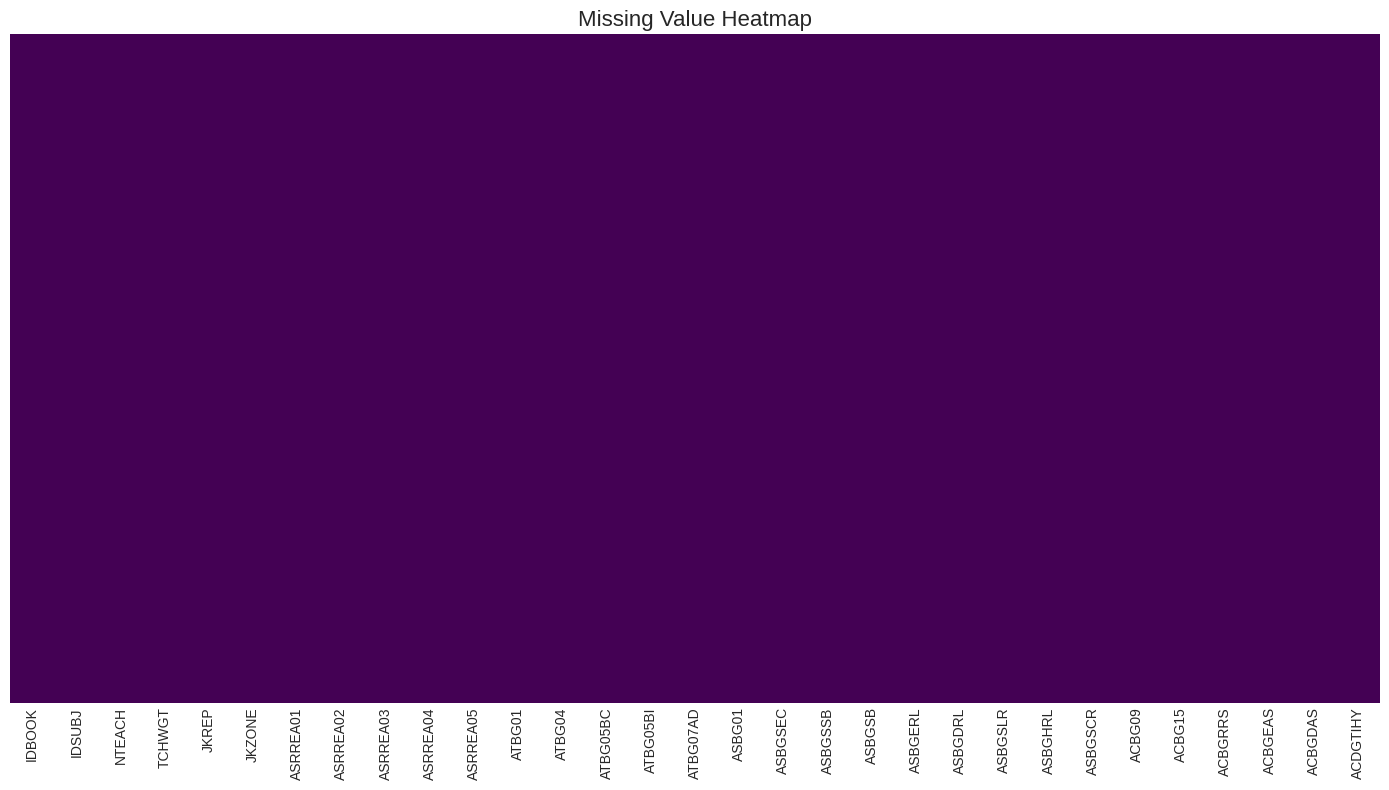

In [27]:
# Visualize missing values
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


## 3. Univariate Analysis

Let's examine the distributions of individual variables.

In [29]:
# Get categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

Categorical columns: 25
Numerical columns: 6


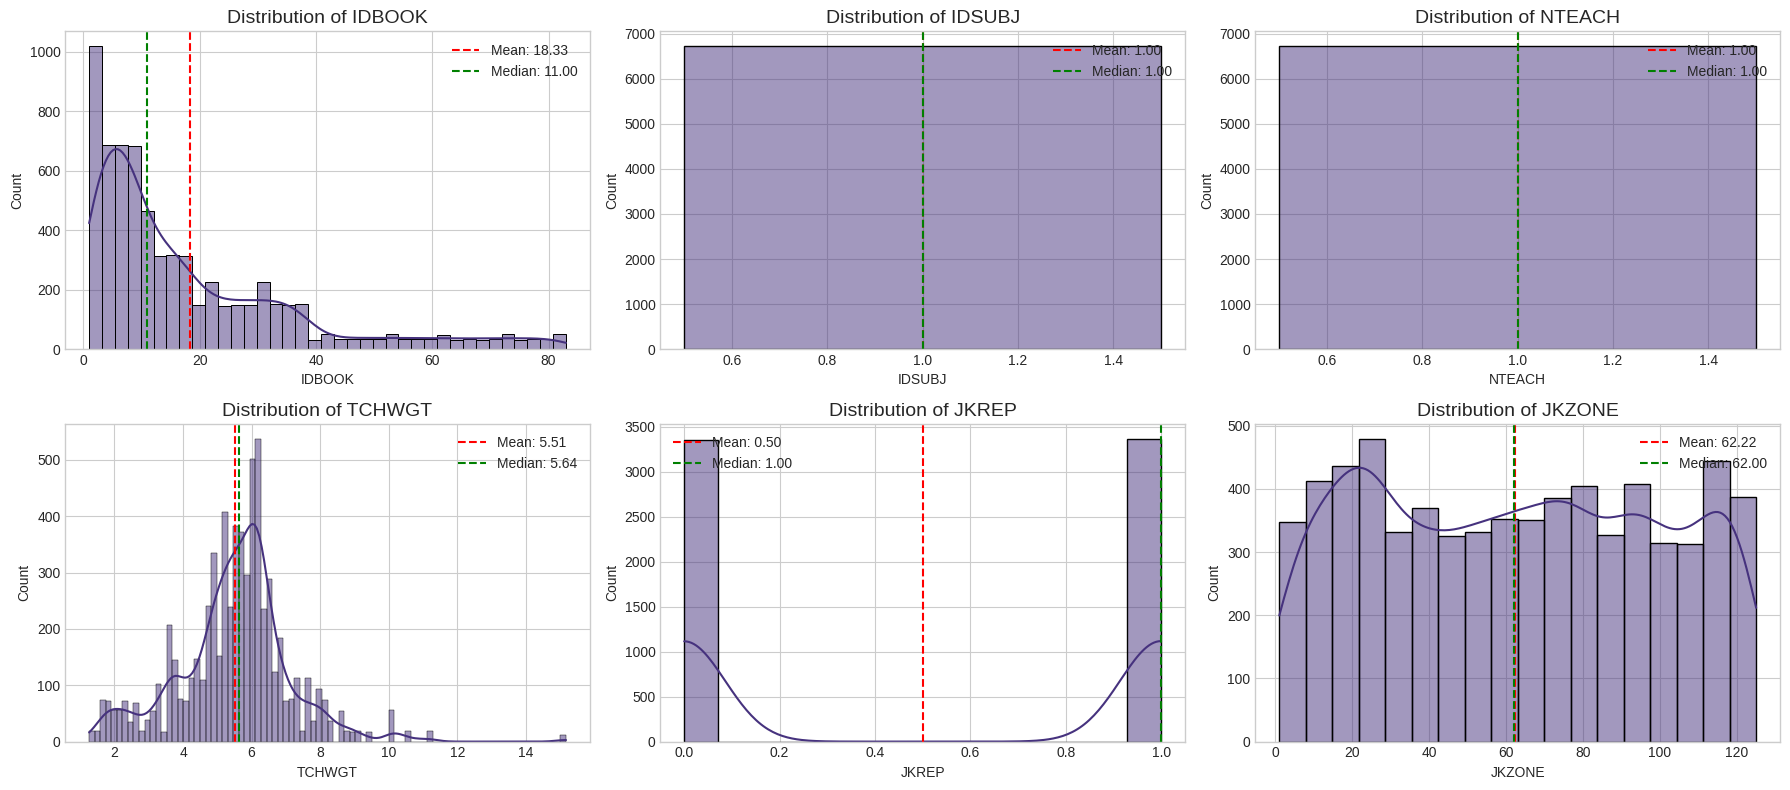

In [30]:
# Distribution of numerical variables
def plot_numerical_distributions(df, cols, n_cols=3):
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=14)
        axes[i].tick_params(labelsize=10)
        
        # Add mean and median lines
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
        axes[i].legend()
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Plot distributions for first 12 numerical columns (adjust as needed)
if len(numerical_cols) > 12:
    plot_numerical_distributions(df, numerical_cols[:12])
    plot_numerical_distributions(df, numerical_cols[12:24])
    # Add more calls if needed
else:
    plot_numerical_distributions(df, numerical_cols)

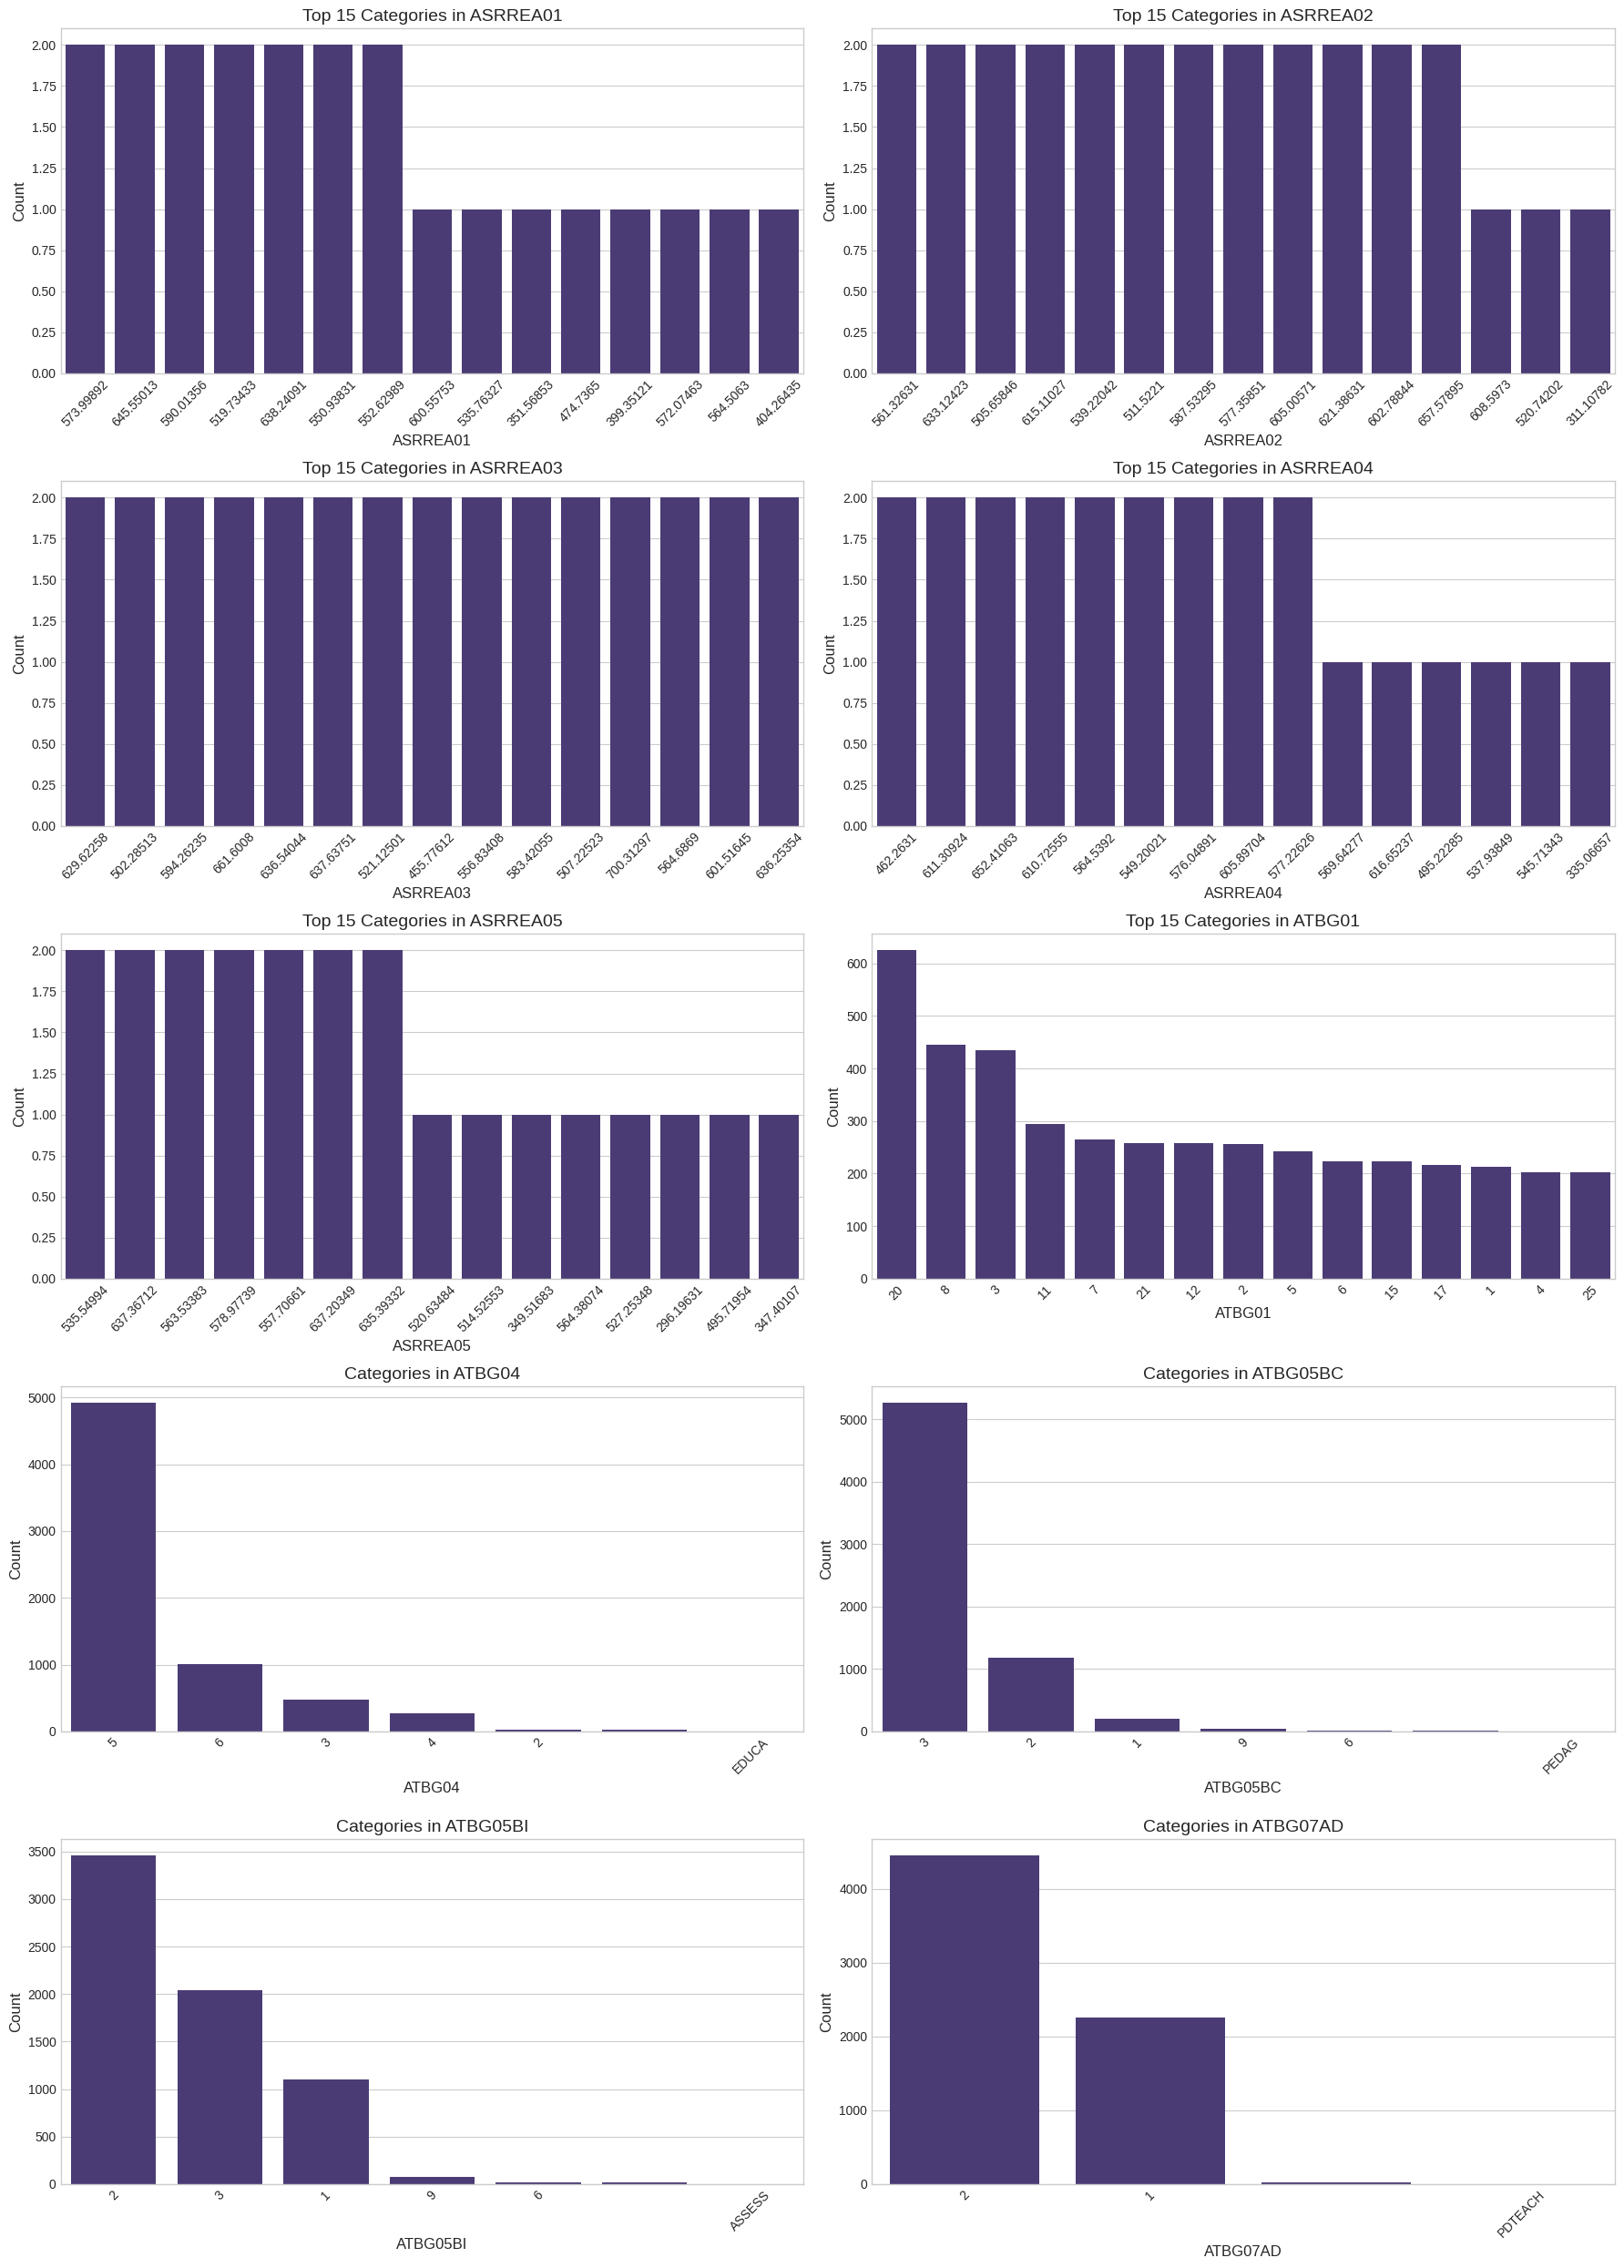

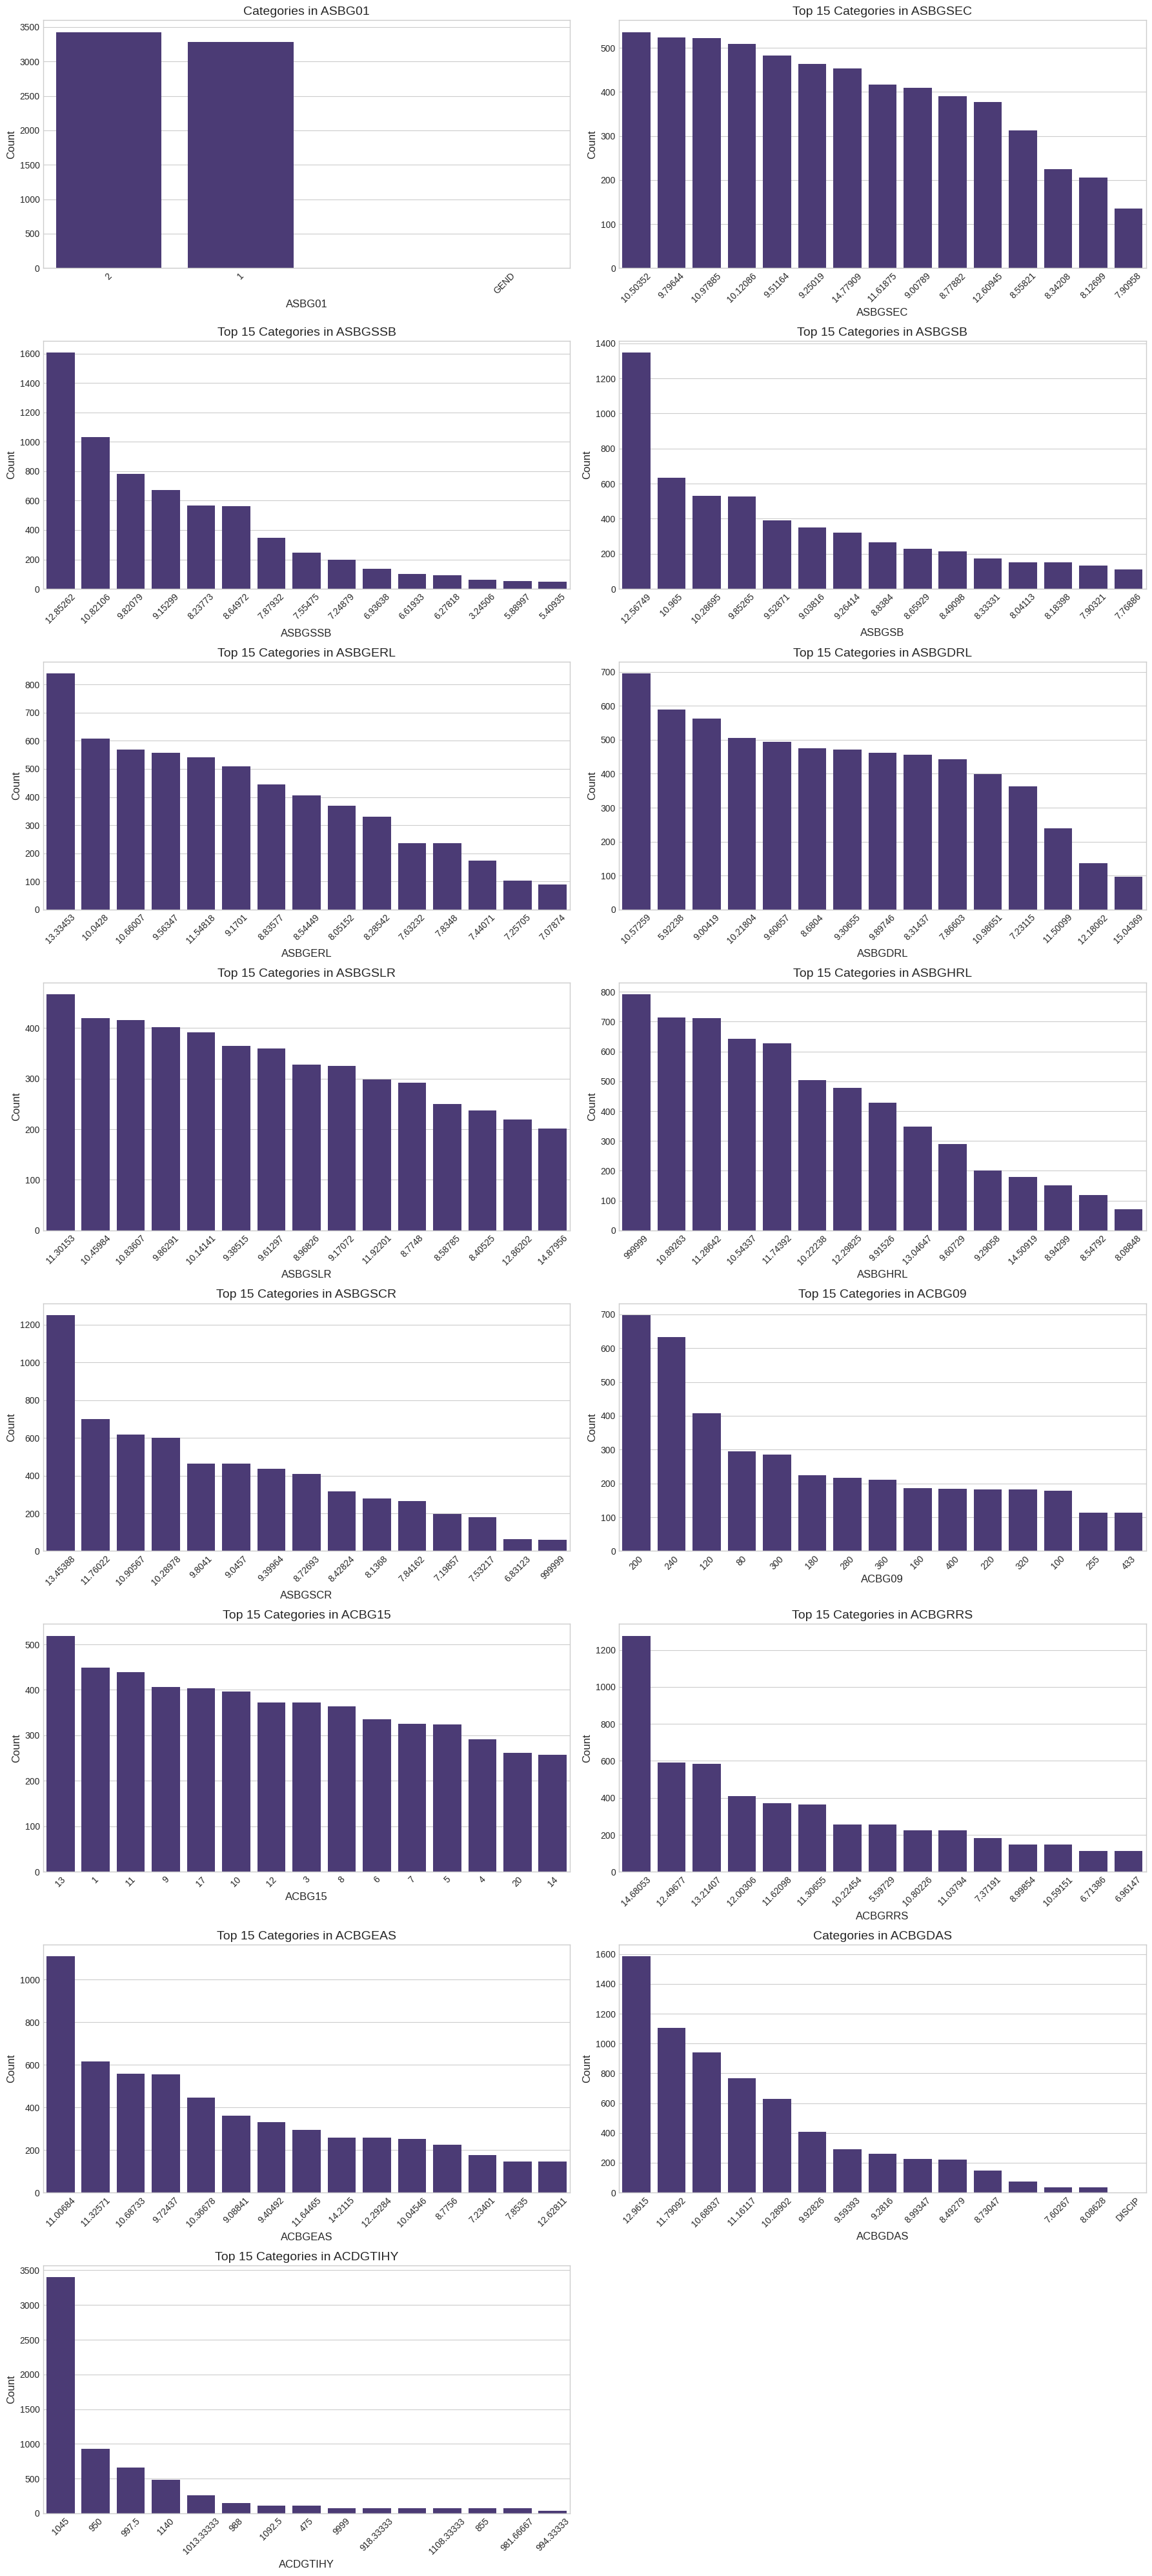

In [31]:
# Distribution of categorical variables
def plot_categorical_distributions(df, cols, n_cols=2):
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        # Get value counts and handle cases with too many unique values
        value_counts = df[col].value_counts()
        
        if len(value_counts) > 15:  # If too many categories, show top 15
            value_counts = value_counts.nlargest(15)
            title = f'Top 15 Categories in {col}'
        else:
            title = f'Categories in {col}'
            
        sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Count', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Plot distributions for categorical columns (adjust as needed)
if len(categorical_cols) > 0:
    if len(categorical_cols) > 10:
        plot_categorical_distributions(df, categorical_cols[:10])
        plot_categorical_distributions(df, categorical_cols[10:])
    else:
        plot_categorical_distributions(df, categorical_cols)

## 4. Bivariate Analysis

Let's analyze relationships between variables.

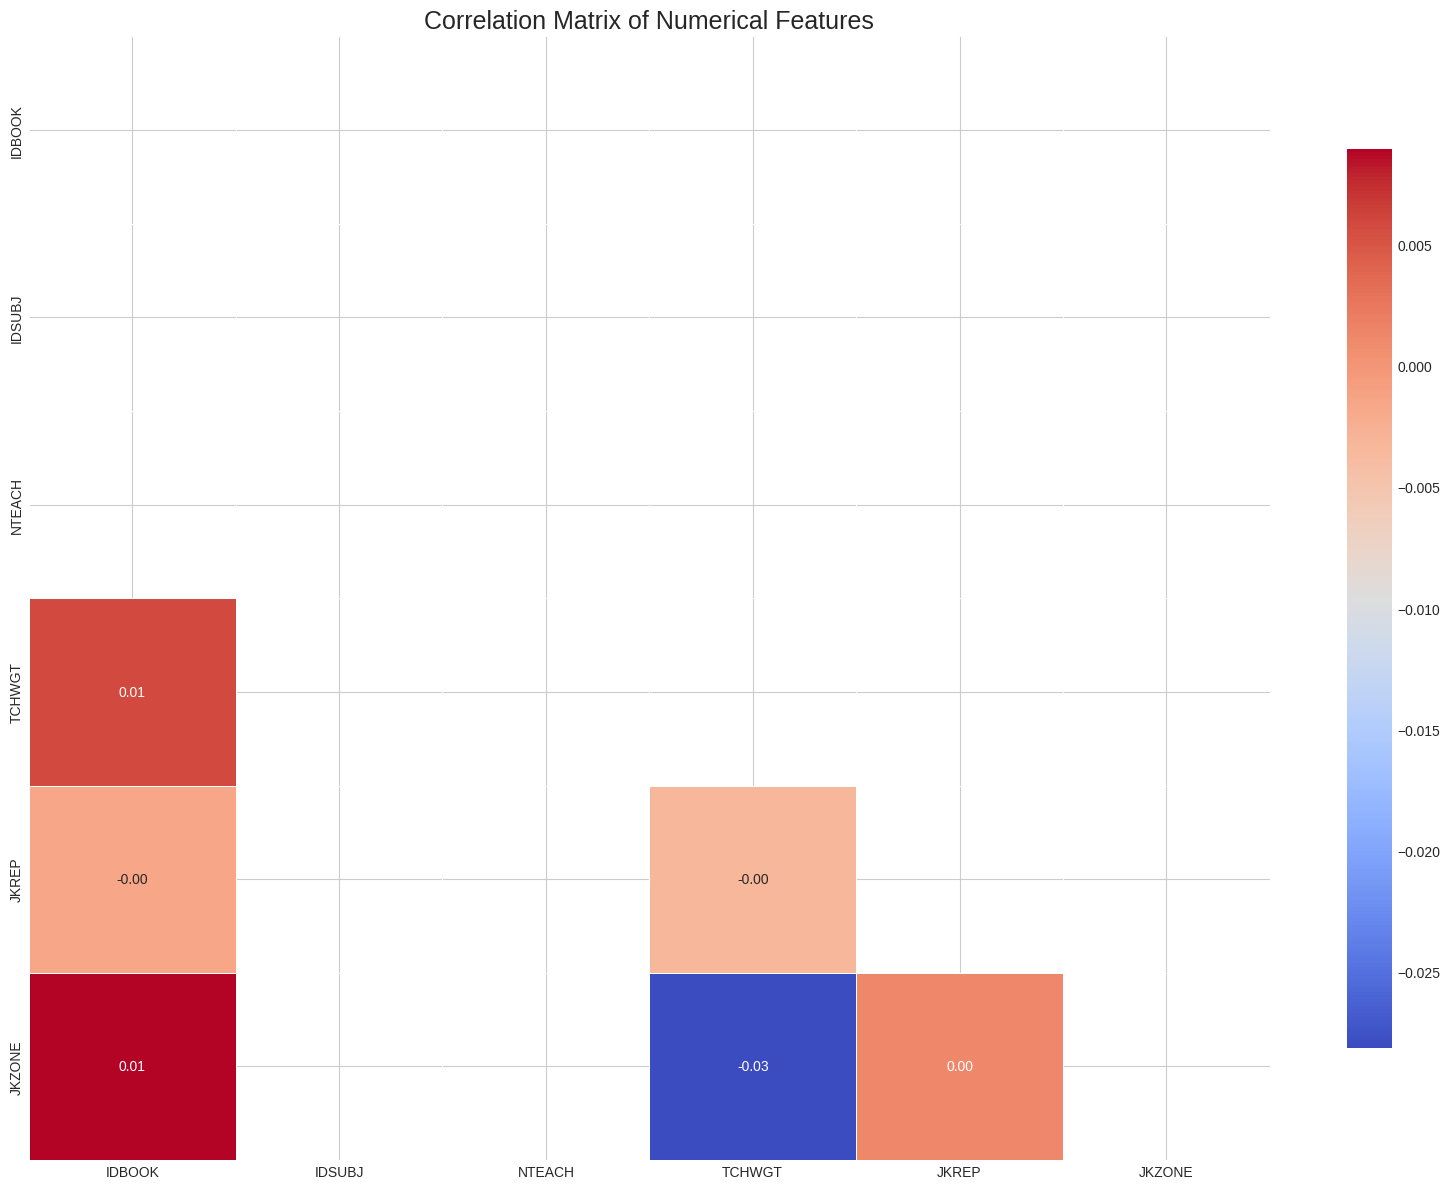

In [32]:
# Correlation matrix for numerical variables
if len(numerical_cols) > 1:
    correlation_matrix = df[numerical_cols].corr()
    
    plt.figure(figsize=(16, 12))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numerical Features', fontsize=18)
    plt.tight_layout()
    plt.show()
    
    # Find and print high correlations
    high_corr = (correlation_matrix.abs() > 0.5) & (correlation_matrix.abs() < 1.0)
    if high_corr.any().any():
        print("\nFeatures with high correlation (|r| > 0.5):")
        for col1 in correlation_matrix.columns:
            for col2 in correlation_matrix.columns:
                if col1 != col2 and high_corr.loc[col1, col2] and col1 < col2:
                    print(f"{col1} -- {col2}: {correlation_matrix.loc[col1, col2]:.3f}")

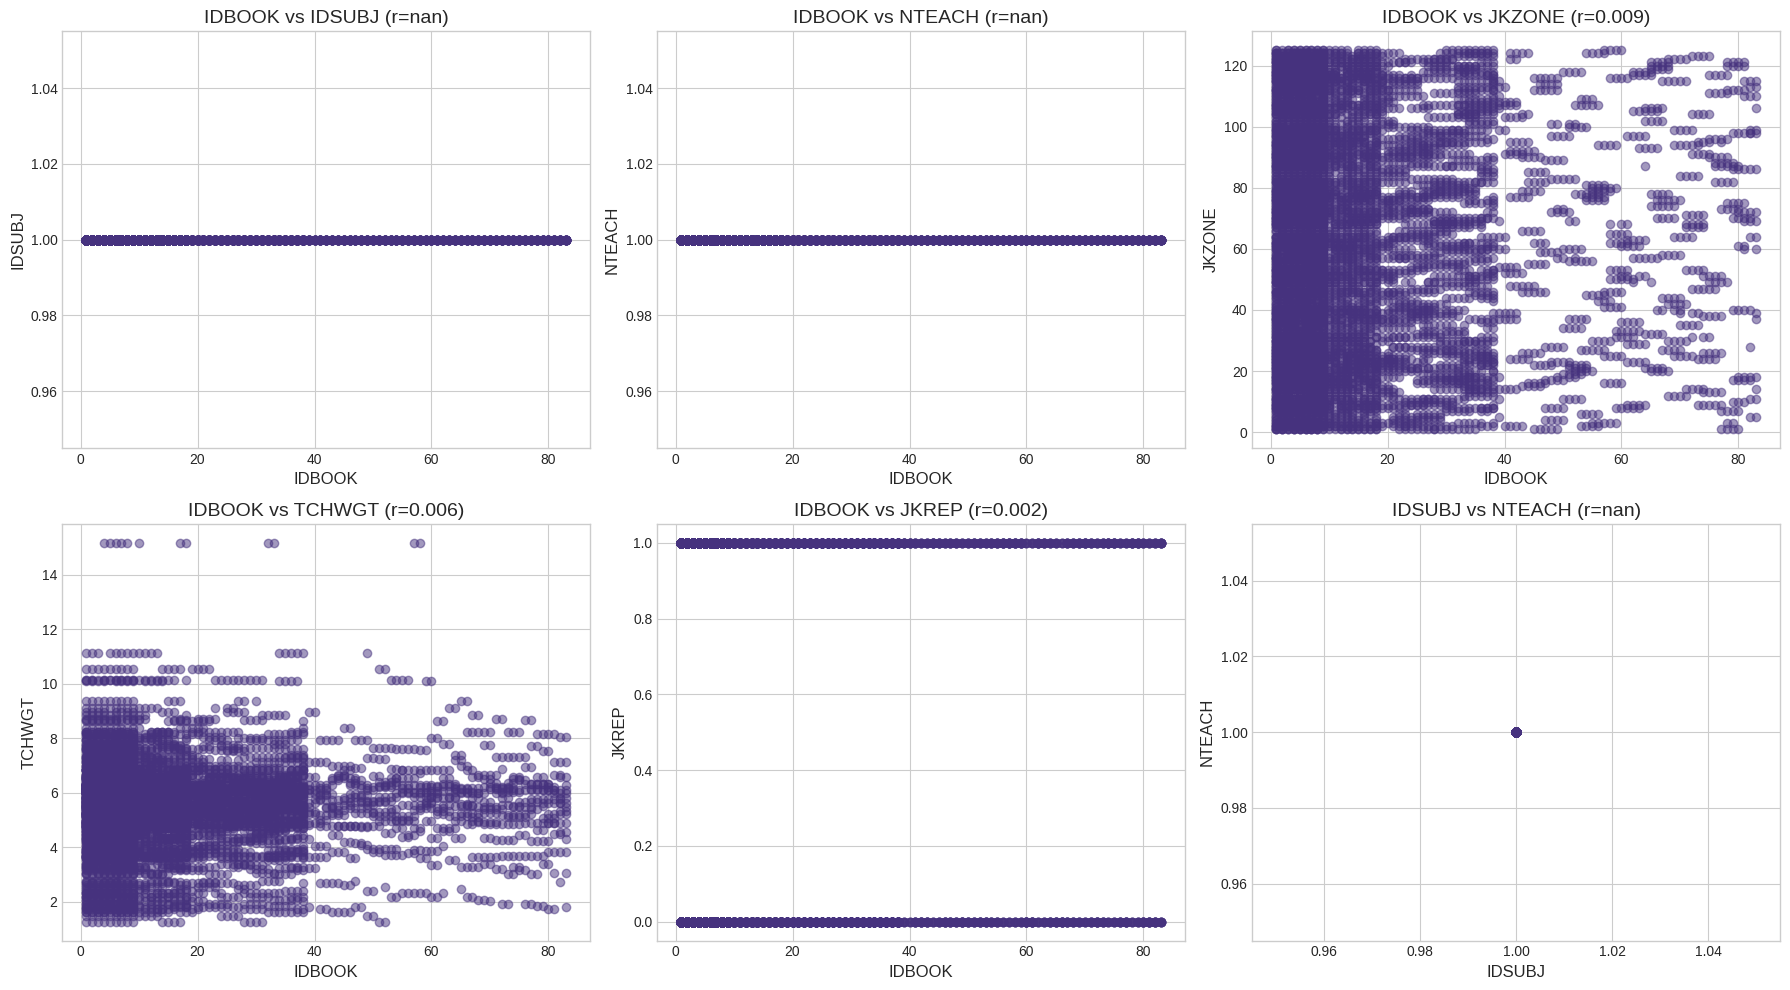

In [33]:
# Scatter plots for highly correlated numerical variables
def plot_scatter_grid(df, cols, n_pairs=6):
    if len(cols) < 2:
        return
    
    # Get high correlation pairs
    corr_matrix = df[cols].corr().abs()
    np.fill_diagonal(corr_matrix.values, 0)
    pairs = []
    
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))
    
    # Sort by correlation (highest first) and take top n_pairs
    pairs.sort(key=lambda x: x[2], reverse=True)
    pairs = pairs[:n_pairs]
    
    # Plot scatter plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, (col1, col2, corr) in enumerate(pairs):
        if i >= len(axes):
            break
        
        axes[i].scatter(df[col1], df[col2], alpha=0.5)
        axes[i].set_title(f'{col1} vs {col2} (r={corr:.3f})', fontsize=14)
        axes[i].set_xlabel(col1, fontsize=12)
        axes[i].set_ylabel(col2, fontsize=12)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# Plot top correlated pairs
if len(numerical_cols) >= 2:
    plot_scatter_grid(df, numerical_cols)

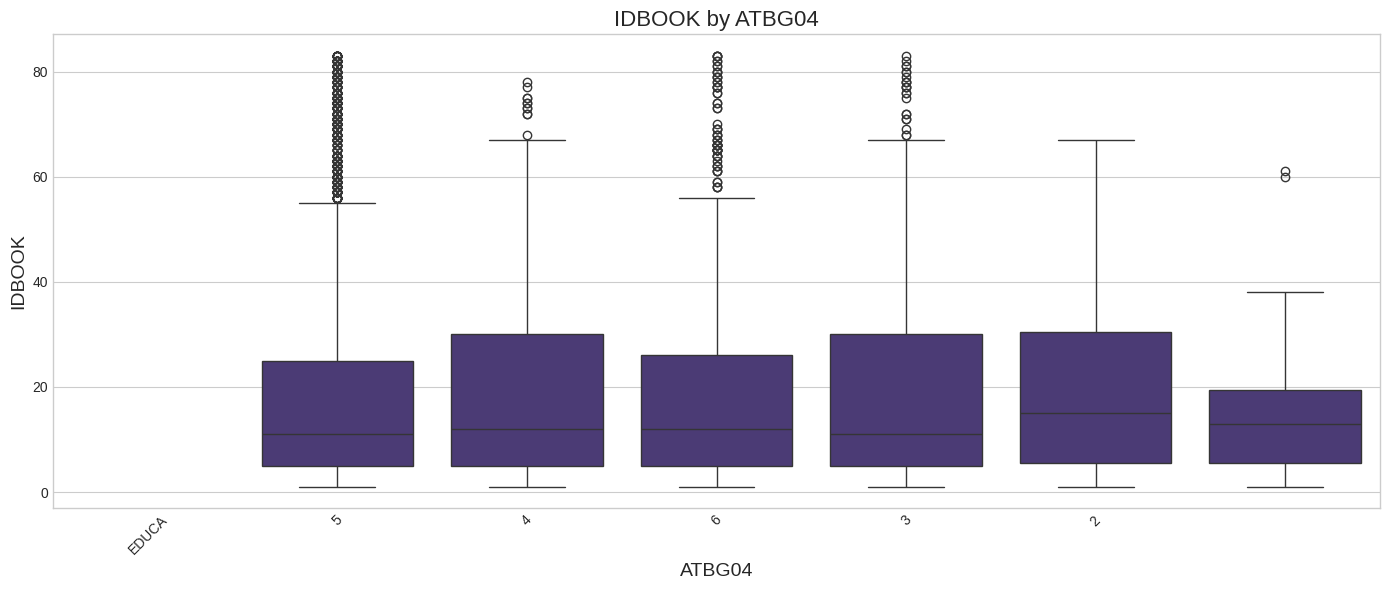

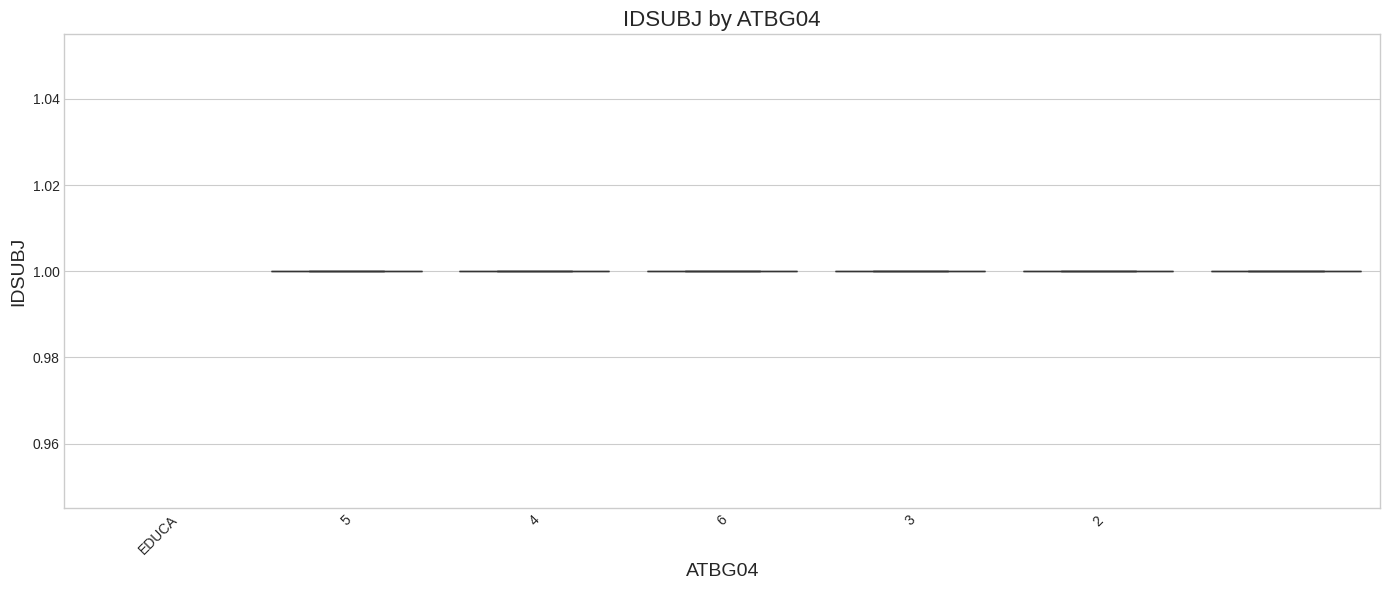

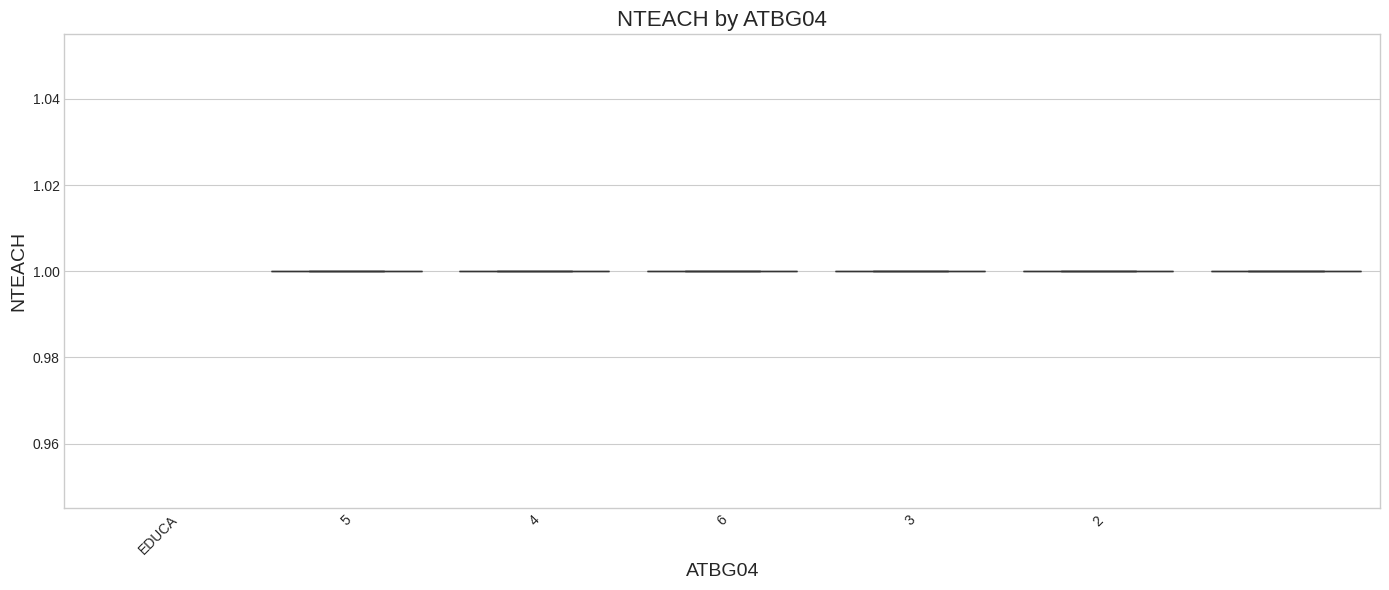

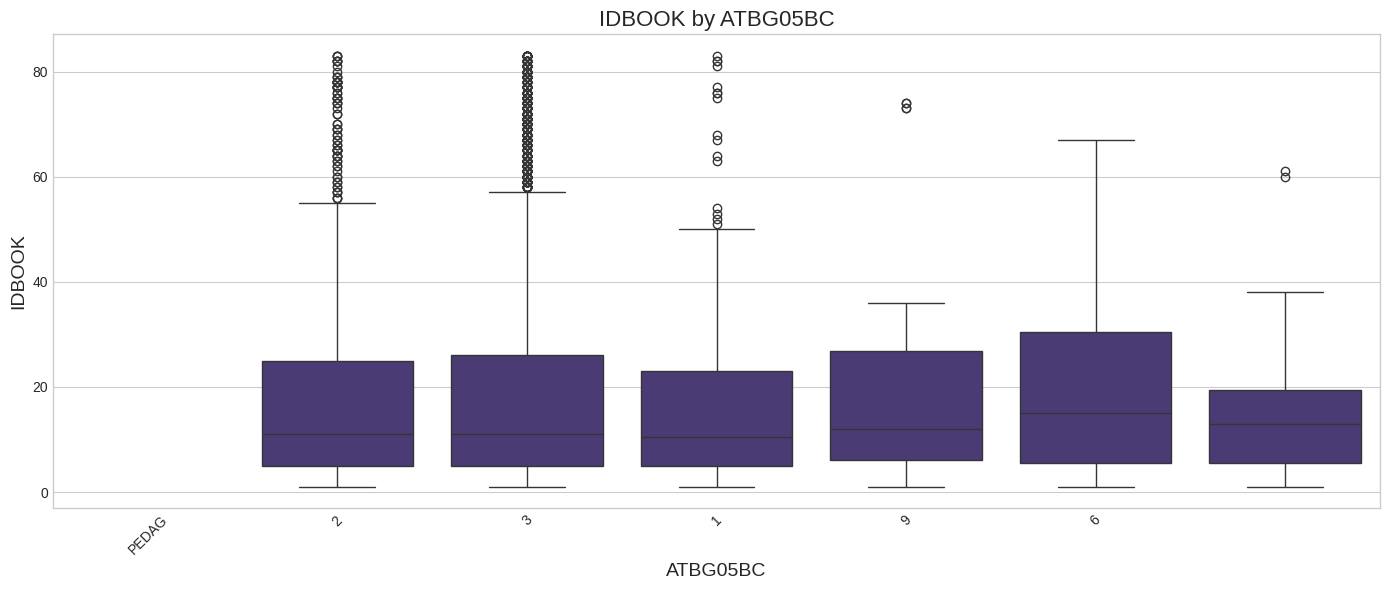

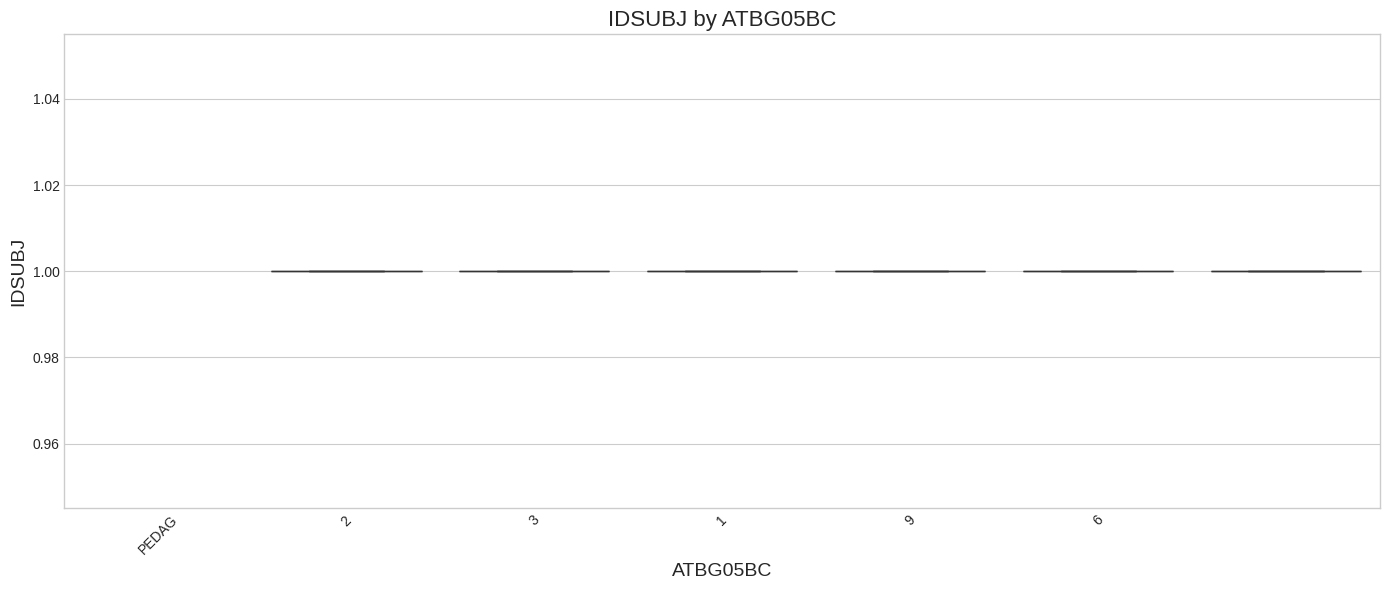

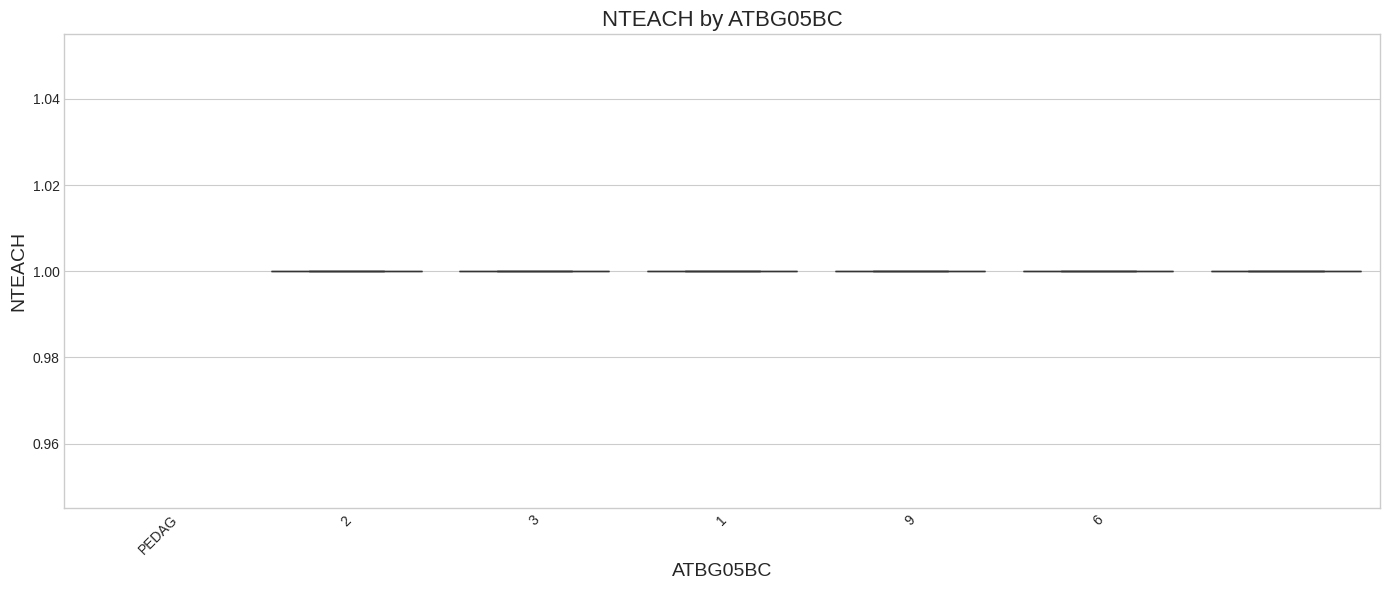

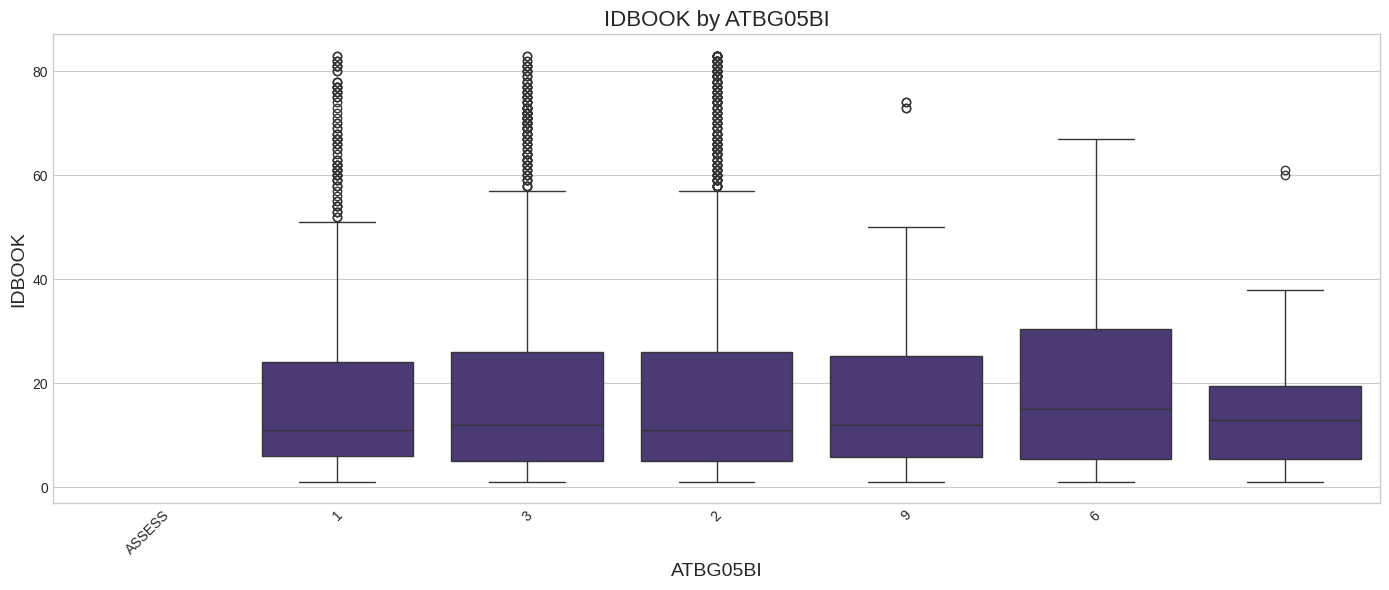

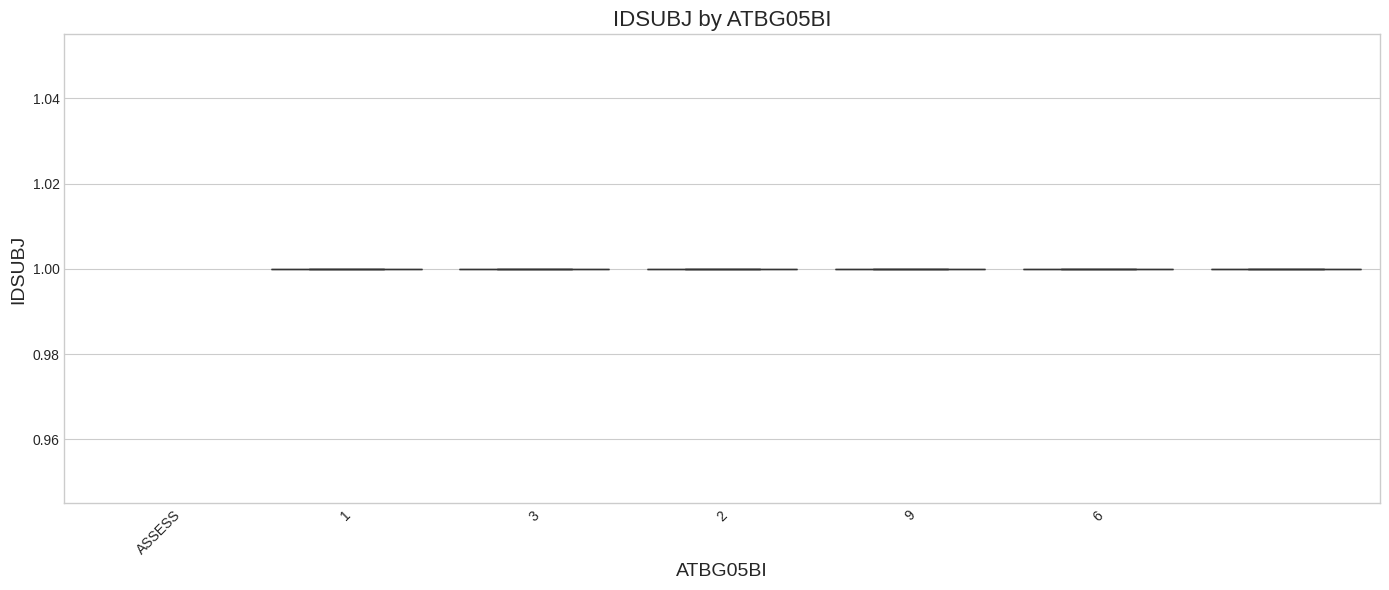

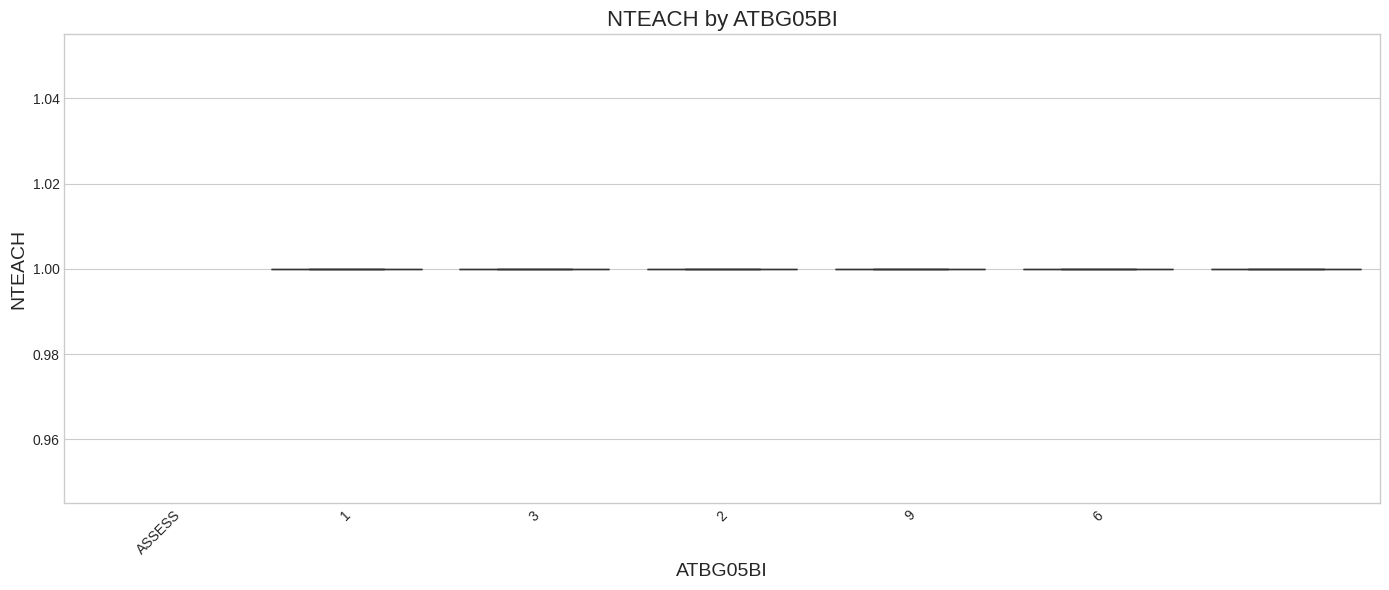

In [34]:
# Categorical vs Numerical Analysis
# Select a few categorical columns with reasonable cardinality for analysis
def analyze_cat_num(df, cat_cols, num_cols):
    cat_cols_for_analysis = []
    for col in cat_cols:
        if 2 <= df[col].nunique() <= 10:  # Only use categorical vars with reasonable cardinality
            cat_cols_for_analysis.append(col)
    
    if not cat_cols_for_analysis or not num_cols:
        return
    
    # Select up to 3 categorical and 3 numerical columns for box plots
    cat_sample = cat_cols_for_analysis[:min(3, len(cat_cols_for_analysis))]
    num_sample = num_cols[:min(3, len(num_cols))]
    
    # Create box plots for each combination
    for cat in cat_sample:
        for num in num_sample:
            plt.figure(figsize=(14, 6))
            sns.boxplot(x=cat, y=num, data=df)
            plt.title(f'{num} by {cat}', fontsize=16)
            plt.xlabel(cat, fontsize=14)
            plt.ylabel(num, fontsize=14)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# Run the categorical vs numerical analysis
analyze_cat_num(df, categorical_cols, numerical_cols)

## 5. Outlier Analysis

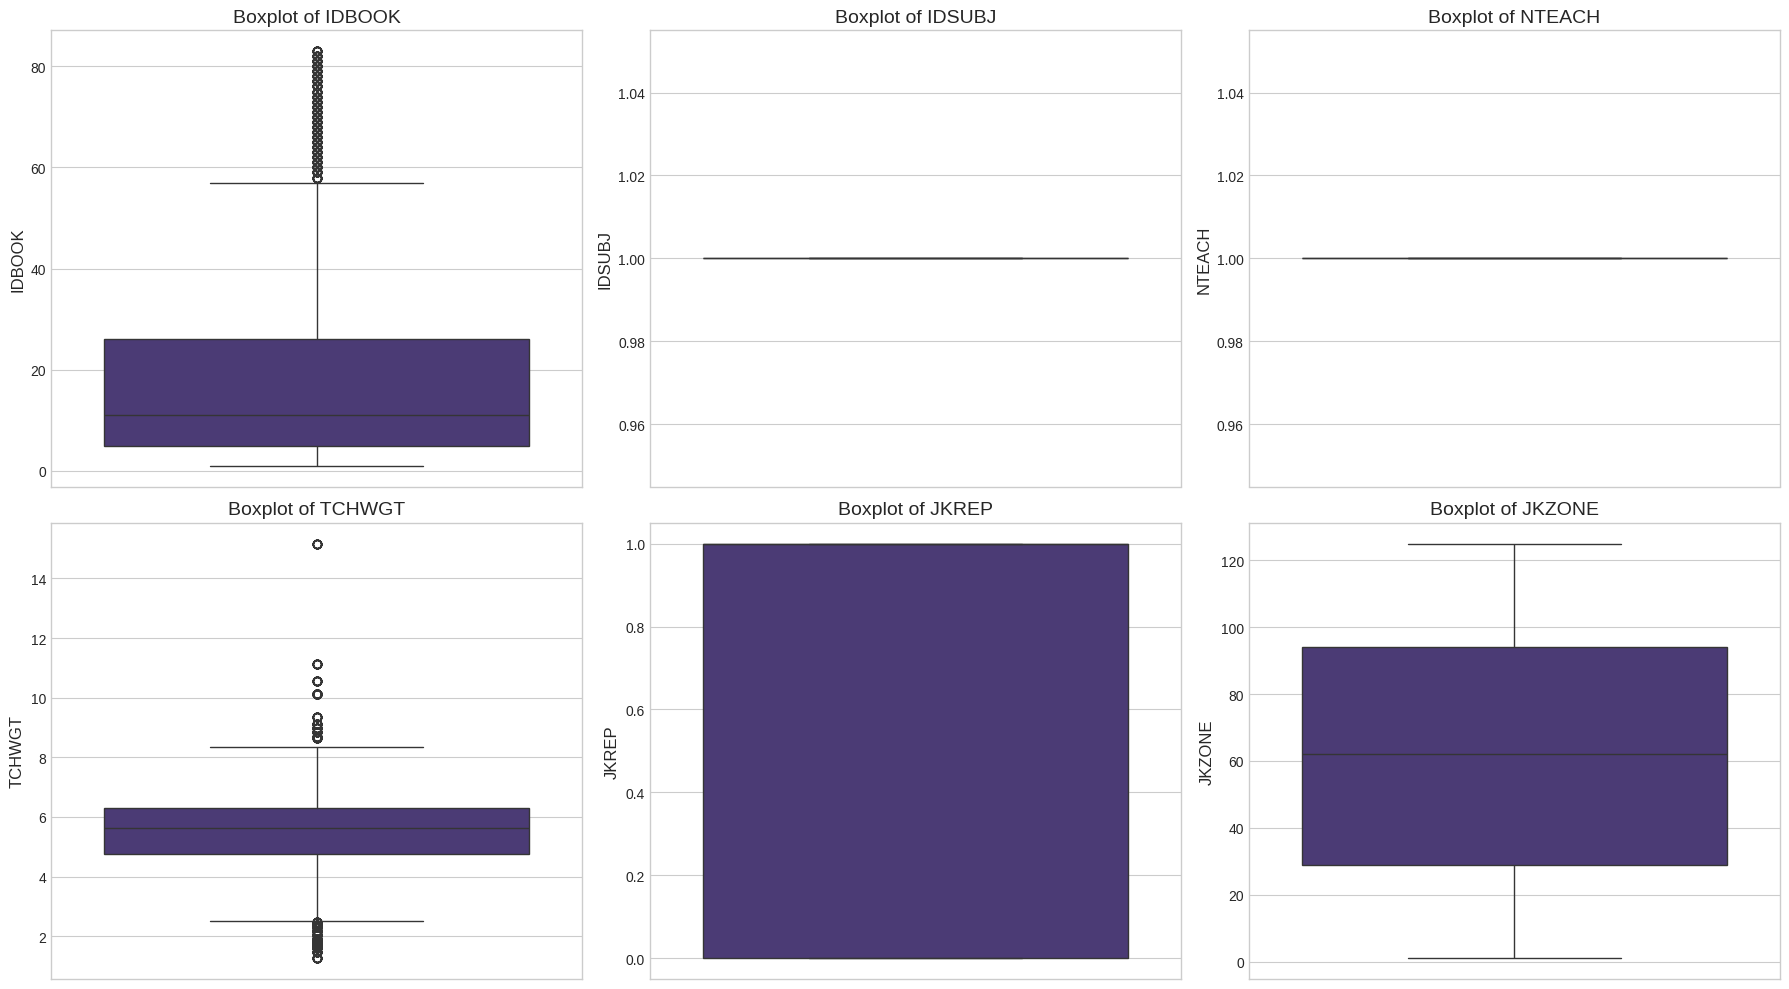

In [35]:
# Box plots for outlier detection
def plot_boxplots(df, cols, n_cols=3):
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}', fontsize=14)
        axes[i].set_xlabel('')
        axes[i].set_ylabel(col, fontsize=12)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Plot boxplots for first 12 numerical columns
if len(numerical_cols) > 0:
    if len(numerical_cols) > 12:
        plot_boxplots(df, numerical_cols[:12])
    else:
        plot_boxplots(df, numerical_cols)

In [36]:
# Identify outliers using IQR method
def detect_outliers(df, cols):
    outlier_info = {}
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outliers_percentage = (outliers_count / len(df)) * 100
        
        outlier_info[col] = {
            'count': outliers_count,
            'percentage': outliers_percentage,
            'bounds': (lower_bound, upper_bound)
        }
    
    # Create a DataFrame for better visualization
    result = pd.DataFrame({
        'Outlier Count': [info['count'] for info in outlier_info.values()],
        'Outlier Percentage (%)': [info['percentage'] for info in outlier_info.values()],
        'Lower Bound': [info['bounds'][0] for info in outlier_info.values()],
        'Upper Bound': [info['bounds'][1] for info in outlier_info.values()]
    }, index=outlier_info.keys())
    
    return result.sort_values('Outlier Percentage (%)', ascending=False)

# Detect outliers in numerical columns
if len(numerical_cols) > 0:
    outlier_summary = detect_outliers(df, numerical_cols)
    print("Outlier Summary:")
    display(outlier_summary)

Outlier Summary:


,Outlier Count,Outlier Percentage (%),Lower Bound,Upper Bound
TCHWGT,614,9.136905,2.473684,8.578948
IDBOOK,428,6.369048,-26.500000,57.500000
IDSUBJ,0,0.000000,1.000000,1.000000
NTEACH,0,0.000000,1.000000,1.000000
JKREP,0,0.000000,-1.500000,2.500000
JKZONE,0,0.000000,-68.500000,191.500000


## 6. Advanced Analysis and Feature Relationships

/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/home/kushal/Documents/xAI Research Project/xai/lib/python3.12/site-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(

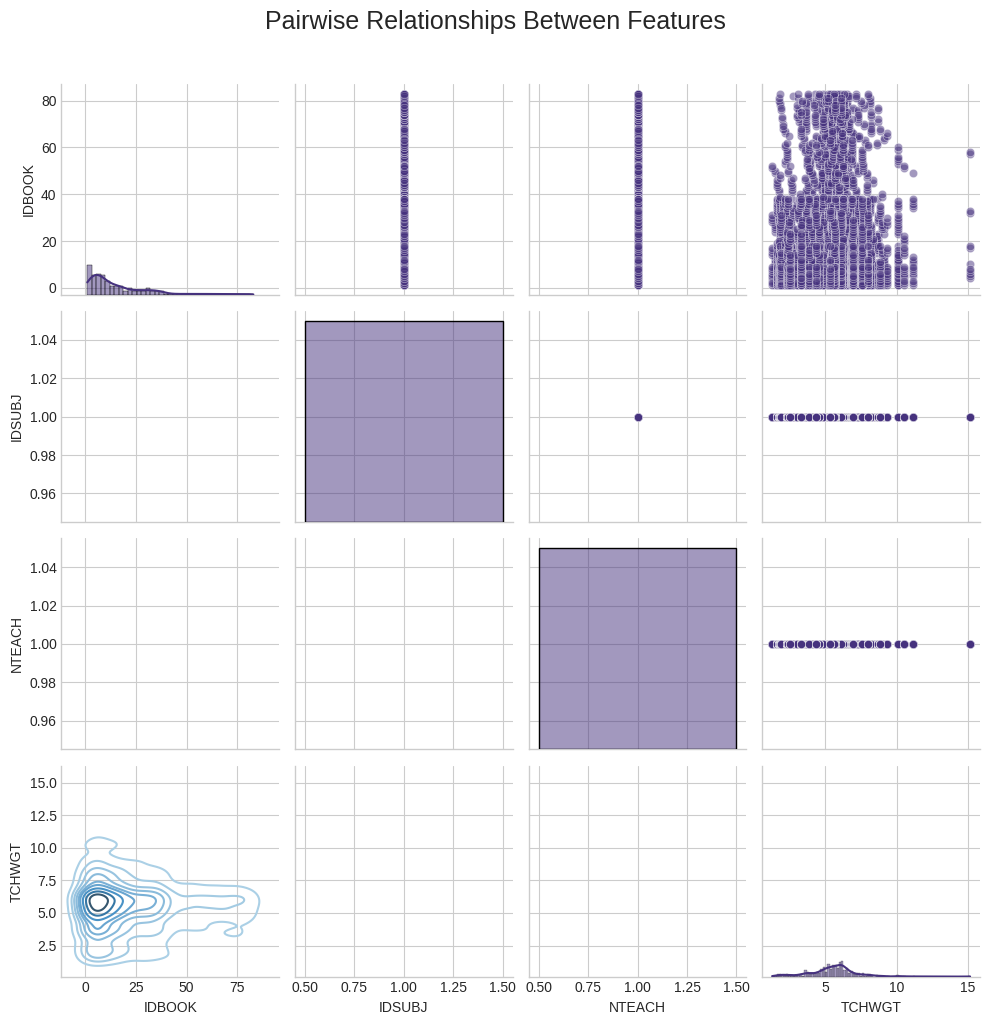

In [37]:
# PairGrid for select numerical variables (choose a few important ones)
if len(numerical_cols) >= 2:
    # Select a few numerical columns (adjust based on your dataset)
    selected_num_cols = numerical_cols[:4] if len(numerical_cols) > 4 else numerical_cols
    
    g = sns.PairGrid(df[selected_num_cols])
    g.map_upper(sns.scatterplot, alpha=0.5)
    g.map_lower(sns.kdeplot, cmap="Blues_d")
    g.map_diag(sns.histplot, kde=True)
    plt.suptitle('Pairwise Relationships Between Features', y=1.02, fontsize=18)
    plt.tight_layout()
    plt.show()

In [38]:
# Distribution comparison if there's a potential target variable
# If any categorical column has 2-3 categories, use it to compare distributions
binary_cat_cols = [col for col in categorical_cols if 2 <= df[col].nunique() <= 3]

if binary_cat_cols and len(numerical_cols) > 0:
    # Use the first binary categorical column to compare distributions
    cat_col = binary_cat_cols[0]
    
    # Get 3-4 most varied numerical columns
    num_cols_by_variance = df[numerical_cols].var().sort_values(ascending=False).index[:4].tolist()
    
    # Plot distribution comparisons
    for num_col in num_cols_by_variance:
        plt.figure(figsize=(14, 6))
        sns.histplot(data=df, x=num_col, hue=cat_col, kde=True, element="step", common_norm=False, alpha=0.5)
        plt.title(f'Distribution of {num_col} by {cat_col}', fontsize=16)
        plt.xlabel(num_col, fontsize=14)
        plt.ylabel('Density', fontsize=14)
        plt.tight_layout()
        plt.show()

## 7. Time Series Analysis (if applicable)

Check if there are date/time columns to perform time series analysis.

In [39]:
# Check for potential datetime columns
datetime_pattern = '|'.join(['date', 'time', 'year', 'month', 'day'])
potential_datetime_cols = [col for col in df.columns if any(pattern in col.lower() for pattern in datetime_pattern.split('|'))]

if potential_datetime_cols:
    print(f"Potential datetime columns: {potential_datetime_cols}")
    
    # Try to convert to datetime (will need to adapt based on actual data)
    for col in potential_datetime_cols:
        try:
            df[f'{col}_dt'] = pd.to_datetime(df[col])
            print(f"Successfully converted {col} to datetime")
            
            # Basic time series plot with a numeric column
            if numerical_cols:
                plt.figure(figsize=(16, 6))
                plt.plot(df[f'{col}_dt'], df[numerical_cols[0]], marker='.', linestyle='-', alpha=0.6)
                plt.title(f'{numerical_cols[0]} over Time', fontsize=16)
                plt.xlabel('Time', fontsize=14)
                plt.ylabel(numerical_cols[0], fontsize=14)
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
        except:
            print(f"Could not convert {col} to datetime")

## 8. Summary and Insights

In [40]:
# Display basic dataset information for summary
print(f"Dataset Shape: {df.shape}")
print(f"Number of Features: {len(df.columns)}")
print(f"Number of Numerical Features: {len(numerical_cols)}")
print(f"Number of Categorical Features: {len(categorical_cols)}")

# Calculate and display memory usage
memory_usage = df.memory_usage(deep=True).sum() / (1024 * 1024)  # Convert to MB
print(f"Memory Usage: {memory_usage:.2f} MB")

# Display unique values in categorical columns
print("\nCardinality of Categorical Features:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Dataset Shape: (6720, 31)
Number of Features: 31
Number of Numerical Features: 6
Number of Categorical Features: 25
Memory Usage: 9.06 MB

Cardinality of Categorical Features:
ASRREA01: 6713 unique values
ASRREA02: 6708 unique values
ASRREA03: 6705 unique values
ASRREA04: 6711 unique values
ASRREA05: 6713 unique values
ATBG01: 46 unique values
ATBG04: 7 unique values
ATBG05BC: 7 unique values
ATBG05BI: 7 unique values
ATBG07AD: 4 unique values
ASBG01: 4 unique values
ASBGSEC: 194 unique values
ASBGSSB: 75 unique values
ASBGSB: 245 unique values
ASBGERL: 201 unique values
ASBGDRL: 80 unique values
ASBGSLR: 268 unique values
ASBGHRL: 86 unique values
ASBGSCR: 103 unique values
ACBG09: 71 unique values
ACBG15: 27 unique values
ACBGRRS: 37 unique values
ACBGEAS: 29 unique values
ACBGDAS: 15 unique values
ACDGTIHY: 20 unique values


## Key Findings and Recommendations

Based on the EDA performed above, here are some key insights and recommendations:

1. **Data Quality Assessment**:
   - Missing values: [Describe patterns of missing values found]
   - Outliers: [Describe significant outliers detected]
   - Data types: [Comment on appropriateness of data types]

2. **Feature Distributions**:
   - [Highlight any features with interesting distributions]
   - [Note any heavily skewed features that might need transformation]

3. **Relationships**:
   - [Describe strong correlations found]
   - [Highlight important relationships between categorical and numerical features]

4. **Next Steps**:
   - Feature engineering opportunities: [Suggest potential derived features]
   - Data cleaning recommendations: [Specific cleaning steps needed]
   - Further analysis: [Areas that might benefit from deeper investigation]

*Note: Please update these sections with specific insights from your dataset after running the analysis.*